# Decision Tree Visualizations

> *Every strategic decision is a node in a tree. The question is how deep you're willing to look.*

## The Question

When a computer plays a game, it doesn't "think" the way people think, it **searches**.
It constructs a tree of possible moves and countermoves, evaluates the outcomes at the leaves,
and picks the branch that leads to the best result, assuming the opponent also plays perfectly.

This is the **minimax algorithm**, and it underlies everything from chess engines to game AI research.

This notebook visualizes that search process:
- What does the tree actually look like?
- How big does it get?
- Where does pruning help, and by how much?

We'll work through three games in increasing complexity:
1. **Tic-tac-toe**:  small enough to visualize the complete game tree
2. **Minimax with alpha-beta pruning**: the insight that makes minimax practical
3. **Connect Four with heuristics**: too large to solve perfectly, so we estimate

In [21]:
# Imports
import math
import random
import time
from copy import deepcopy
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0f1923",
    "axes.facecolor":   "#0f1923",
    "axes.edgecolor":   "#334455",
    "axes.labelcolor":  "#c8d8e8",
    "xtick.color":      "#c8d8e8",
    "ytick.color":      "#c8d8e8",
    "text.color":       "#c8d8e8",
    "grid.color":       "#1e3040",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
})

print("Imports complete.")

Imports complete.


## Tic-Tac-Toe: The Complete Game Tree

The full tic-tac-toe game tree has roughly 255,168 terminal states
(before accounting for symmetry). It's small enough that minimax can
solve it perfectly and fast enough that we can visualize meaningful
slices of the tree.

**Insight:** Optimal play from both sides always ends in a draw.
Minimax will prove this.

### Board representation
We represent the board as a flat tuple of 9 values:
`0` = empty, `1` = X, `-1` = O.
Player X always moves first and maximizes; player O minimizes.

In [22]:
# Tic-tac-toe engine

EMPTY, X, O = 0, 1, -1

def empty_board():
    return (0,) * 9

def get_winner(board):
    lines = [
        (0,1,2),(3,4,5),(6,7,8),  # rows
        (0,3,6),(1,4,7),(2,5,8),  # cols
        (0,4,8),(2,4,6),           # diagonals
    ]
    for a, b, c in lines:
        if board[a] != EMPTY and board[a] == board[b] == board[c]:
            return board[a]
    return None

def is_terminal(board):
    return get_winner(board) is not None or EMPTY not in board

def get_moves(board):
    return [i for i, v in enumerate(board) if v == EMPTY]

def make_move(board, pos, player):
    lst = list(board)
    lst[pos] = player
    return tuple(lst)

def board_str(board):
    symbols = {X: "X", O: "O", EMPTY: "."}
    rows = []
    for r in range(3):
        rows.append(" ".join(symbols[board[r*3 + c]] for c in range(3)))
    return "\n".join(rows)

# Quick sanity check
b = make_move(empty_board(), 4, X)
b = make_move(b, 0, O)
print(board_str(b))
print("Winner:", get_winner(b))

O . .
. X .
. . .
Winner: None


In [23]:
# Minimax for tic-tac-toe

def minimax(board, player, memo=None):
    """
    Returns the minimax value of the board for the current player.
    X (1) maximizes; O (-1) minimizes.
    Uses memoization so each unique board is evaluated once.
    """
    if memo is None:
        memo = {}
    if board in memo:
        return memo[board]

    winner = get_winner(board)
    if winner is not None:
        return winner           # +1 for X win, -1 for O win
    if EMPTY not in board:
        return 0                # Draw

    moves = get_moves(board)
    scores = [
        minimax(make_move(board, m, player), -player, memo)
        for m in moves
    ]

    result = max(scores) if player == X else min(scores)
    memo[board] = result
    return result

def best_move(board, player):
    """Return the index of the best move for the given player."""
    memo = {}
    best_score = -math.inf if player == X else math.inf
    best_m = None
    for m in get_moves(board):
        score = minimax(make_move(board, m, player), -player, memo)
        if (player == X and score > best_score) or            (player == O and score < best_score):
            best_score = score
            best_m = m
    return best_m

# Solve the empty board — should always return 0 (draw with perfect play)
result = minimax(empty_board(), X)
print(f"Minimax value of the starting position: {result}")
print("0 = Draw, +1 = X wins, -1 = O wins")
print()
print("Optimal play always ends in a draw. Proven.")

Minimax value of the starting position: 0
0 = Draw, +1 = X wins, -1 = O wins

Optimal play always ends in a draw. Proven.


### Visualizing the early game tree

The full tree is too large to display, so we visualize the first two
plies (X's opening move and O's response). Each node is colored by its
minimax value: green for X advantage, red for O advantage, gray for draw.

In [24]:
def build_tree(board, player, depth, max_depth, G, parent_id=None, move=None, counter=None):
    """
    Recursively build a NetworkX DiGraph of the game tree up to max_depth.
    Returns node count (passed as mutable list for recursion).
    """
    if counter is None:
        counter = [0]

    node_id = counter[0]
    counter[0] += 1

    winner  = get_winner(board)
    is_term = is_terminal(board)
    value   = minimax(board, player)

    G.add_node(node_id, board=board, player=player,
               value=value, terminal=is_term,
               move=move, depth=depth)

    if parent_id is not None:
        G.add_edge(parent_id, node_id, move=move)

    if depth < max_depth and not is_term:
        for m in get_moves(board):
            child_board = make_move(board, m, player)
            build_tree(child_board, -player, depth+1, max_depth,
                       G, node_id, m, counter)
    return G

# Build the first 2 plies
G = nx.DiGraph()
build_tree(empty_board(), X, 0, 2, G)
print(f"Nodes in tree (depth ≤ 2): {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes in tree (depth ≤ 2): 82
Edges: 81


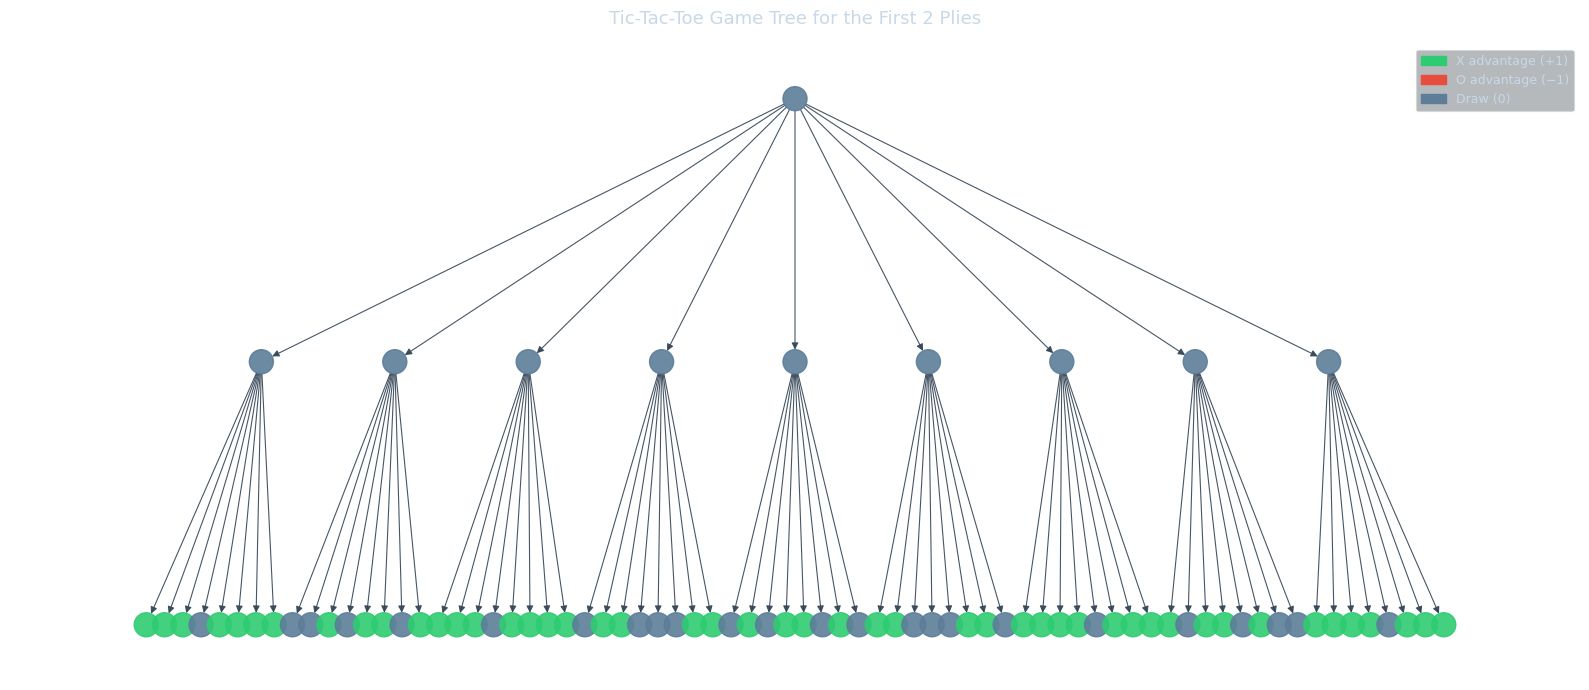

In [25]:
def draw_game_tree(G, title="Game Tree"):
    """Draw the game tree using a top-down hierarchical layout."""
    # Build positional layout with hierarchy by depth
    depth_nodes = defaultdict(list)
    for n, data in G.nodes(data=True):
        depth_nodes[data["depth"]].append(n)

    pos = {}
    for depth, nodes in depth_nodes.items():
        n = len(nodes)
        for i, node in enumerate(nodes):
            pos[node] = ((i + 1) / (n + 1), -depth * 1.2)

    value_colors = {1: "#2ecc71", -1: "#e74c3c", 0: "#5d7d99"}
    node_colors  = [
        value_colors.get(G.nodes[n]["value"], "#5d7d99")
        for n in G.nodes()
    ]
    node_sizes = [
        500 if G.nodes[n]["terminal"] else 300
        for n in G.nodes()
    ]

    fig, ax = plt.subplots(figsize=(16, 7))
    nx.draw(
        G, pos, ax=ax,
        node_color=node_colors, node_size=node_sizes,
        edge_color="#334455", arrows=True,
        arrowsize=10, width=0.8, alpha=0.9,
        with_labels=False,
    )

    # Legend
    patches = [
        mpatches.Patch(color="#2ecc71", label="X advantage (+1)"),
        mpatches.Patch(color="#e74c3c", label="O advantage (−1)"),
        mpatches.Patch(color="#5d7d99", label="Draw (0)"),
    ]
    ax.legend(handles=patches, loc="upper right",
              framealpha=0.3, fontsize=9)
    ax.set_title(title, fontsize=13, pad=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

draw_game_tree(G, title="Tic-Tac-Toe Game Tree for the First 2 Plies")

In [26]:
# How many nodes are at each depth?
# Full tree size to illustrate exponential growth

print("TTT GAME TREE NODE COUNT BY DEPTH")
print(f"  {'Depth':<8} {'Nodes (sample)':<18} {'Branching'}")
prev = 1
for d in range(1, 6):
    G_d = nx.DiGraph()
    build_tree(empty_board(), X, 0, d, G_d)
    n = G_d.number_of_nodes()
    factor = n / prev if prev > 0 else "--"
    print(f"  {d:<8} {n:<18,} {factor:.1f}x")
    prev = n

print()
print("The tree grows roughly 6-8x per ply early on.")
print("Alpha-beta pruning (Part 2) dramatically reduces this.")

TTT GAME TREE NODE COUNT BY DEPTH
  Depth    Nodes (sample)     Branching
  1        10                 10.0x
  2        82                 8.2x
  3        586                7.1x
  4        3,610              6.2x
  5        18,730             5.2x

The tree grows roughly 6-8x per ply early on.
Alpha-beta pruning (Part 2) dramatically reduces this.


### Optimal vs. Random: Does minimax actually win?

Let's empirically verify that minimax never loses by pitting it
against a random player across many games. In the first scenario, X plays perfectly, while O plays randomly. 
X should always win in this scenario.

Minimax (X) vs Random (O) 500 games
  X wins  :  500  (100.0%)
  O wins  :    0  (0.0%)
  Draws   :    0  (0.0%)

Minimax should NEVER lose. O wins = 0 confirms correctness.


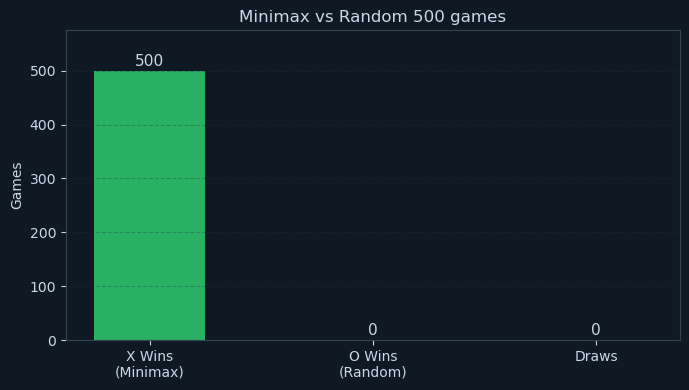

In [27]:
def play_game(x_strategy, o_strategy, verbose=False):
    """
    Play one game. Strategies are callables: f(board, player) to move index.
    Returns +1 (X wins), -1 (O wins), 0 (draw).
    """
    board = empty_board()
    player = X
    while not is_terminal(board):
        strategy = x_strategy if player == X else o_strategy
        move = strategy(board, player)
        board = make_move(board, move, player)
        if verbose:
            print(board_str(board), "\n")
        player = -player
    return get_winner(board) or 0

def random_strategy(board, player):
    return random.choice(get_moves(board))

def minimax_strategy(board, player):
    return best_move(board, player)

# Run 500 games: minimax (X) vs random (O)
N = 500
results = [play_game(minimax_strategy, random_strategy) for _ in range(N)]
x_wins   = results.count(1)
o_wins   = results.count(-1)
draws    = results.count(0)

print(f"Minimax (X) vs Random (O) {N} games")
print(f"  X wins  : {x_wins:>4}  ({x_wins/N*100:.1f}%)")
print(f"  O wins  : {o_wins:>4}  ({o_wins/N*100:.1f}%)")
print(f"  Draws   : {draws:>4}  ({draws/N*100:.1f}%)")
print()
print("Minimax should NEVER lose. O wins = 0 confirms correctness.")

# Visual
fig, ax = plt.subplots(figsize=(7, 4))
cats    = ["X Wins\n(Minimax)", "O Wins\n(Random)", "Draws"]
counts  = [x_wins, o_wins, draws]
colors  = ["#2ecc71", "#e74c3c", "#5d7d99"]
bars    = ax.bar(cats, counts, color=colors, alpha=0.85, width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(count), ha="center", va="bottom", fontsize=11, color="#c8d8e8")
ax.set_ylabel("Games", fontsize=10)
ax.set_title(f"Minimax vs Random {N} games", fontsize=12)
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# If we try Minmax vs. Minmax, we should always see a draw
# Should be: 0 X wins, 0 O wins, 100 draws, proving the theorem.

results = [play_game(minimax_strategy, minimax_strategy) for _ in range(100)]
print(results.count(1), results.count(-1), results.count(0))


0 0 100


In [29]:
# To see vary depth to see how it affects strength  
def minimax_depth_strategy(depth):
    memo = {}
    def strategy(board, player):
        # Limited-depth minimax -- interesting for shallow depths
        def mm(board, player, d):
            if d == 0 or is_terminal(board):
                return minimax(board, player, memo)  # use full eval at leaf
            moves = get_moves(board)
            scores = [mm(make_move(board, m, player), -player, d-1) for m in moves]
            return max(scores) if player == X else min(scores)
        best_score = -math.inf if player == X else math.inf
        best_m = None
        for m in get_moves(board):
            score = mm(make_move(board, m, player), -player, depth-1)
            if (player == X and score > best_score) or \
               (player == O and score < best_score):
                best_score = score
                best_m = m
        return best_m
    return strategy

# This would show gradual improvement as depth increases
for depth in [1, 2, 3, 4, "full"]:
    strategy = minimax_strategy if depth == "full" else minimax_depth_strategy(depth)
    results = [play_game(strategy, random_strategy) for _ in range(200)]
    print(f"Depth {depth}: X wins {results.count(1)}, draws {results.count(0)}, O wins {results.count(-1)}")

Depth 1: X wins 198, draws 2, O wins 0
Depth 2: X wins 199, draws 1, O wins 0
Depth 3: X wins 197, draws 3, O wins 0
Depth 4: X wins 199, draws 1, O wins 0
Depth full: X wins 199, draws 1, O wins 0


## Alpha-Beta Pruning
Minimax searches every possible position. Alpha-beta pruning is the
insight that lets us **skip branches that can't possibly affect
the final decision**, without changing the result.

### The intuition
Suppose you're choosing between two paths:
- Path A leads to a guaranteed score of 5
- You're evaluating Path B and find a move that *limits* it to at most 3

You can stop evaluating Path B. It cannot be better than A.

Alpha-beta tracks two bounds:
- **α (alpha)**: the best score the *maximizing* player is guaranteed so far
- **β (beta)**: the best score the *minimizing* player is guaranteed so far

When β ≤ α, the current branch is irrelevant and we prune it.

In [30]:
# Alpha-beta minimax

def minimax_ab(board, player, alpha, beta, nodes_searched):
    """
    Minimax with alpha-beta pruning.
    nodes_searched: mutable list [count] incremented on each call.
    Returns (value, nodes_searched_count).
    """
    nodes_searched[0] += 1

    winner = get_winner(board)
    if winner is not None:
        return winner
    if EMPTY not in board:
        return 0

    if player == X:
        best = -math.inf
        for m in get_moves(board):
            score = minimax_ab(make_move(board, m, player),
                               -player, alpha, beta, nodes_searched)
            best  = max(best, score)
            alpha = max(alpha, best)
            if beta <= alpha:
                break          # Beta cutoff: prune remaining siblings
        return best
    else:
        best = math.inf
        for m in get_moves(board):
            score = minimax_ab(make_move(board, m, player),
                               -player, alpha, beta, nodes_searched)
            best  = min(best, score)
            beta  = min(beta, best)
            if beta <= alpha:
                break          # Alpha cutoff
        return best

def count_nodes(board, player, use_ab):
    counter = [0]
    if use_ab:
        minimax_ab(board, player, -math.inf, math.inf, counter)
    else:
        def mm(board, player):
            counter[0] += 1
            winner = get_winner(board)
            if winner is not None: return winner
            if EMPTY not in board: return 0
            scores = [mm(make_move(board, m, player), -player)
                      for m in get_moves(board)]
            return max(scores) if player == X else min(scores)
        mm(board, player)
    return counter[0]

# Compare from the starting position
n_plain = count_nodes(empty_board(), X, use_ab=False)
n_ab    = count_nodes(empty_board(), X, use_ab=True)

print(f"Nodes searched = plain minimax  : {n_plain:>8,}")
print(f"Nodes searched = alpha-beta     : {n_ab:>8,}")
print(f"Reduction                       : {(1 - n_ab/n_plain)*100:.1f}% fewer nodes")
print(f"Speedup factor                  : {n_plain/n_ab:.1f}x")

Nodes searched = plain minimax  :  549,946
Nodes searched = alpha-beta     :   18,297
Reduction                       : 96.7% fewer nodes
Speedup factor                  : 30.1x


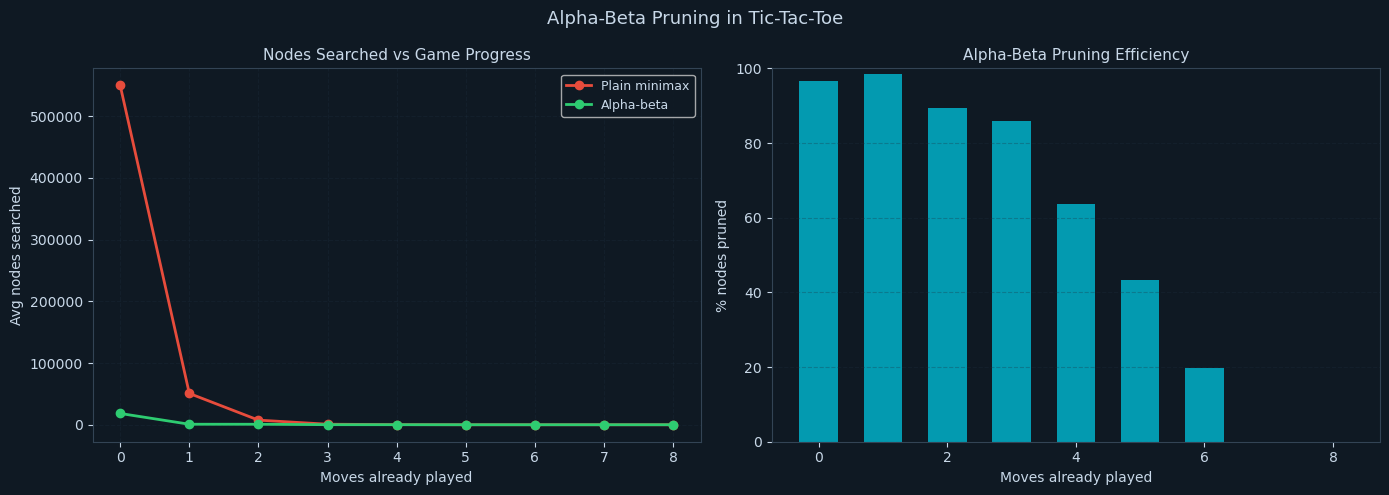

Early in the game pruning helps most because there are more branches to cut.
Late in the game there is little left to prune.


In [31]:
# Pruning efficiency from different board positions
# How much does pruning help as the game progresses (fewer empty squares)?

def random_board_after_k_moves(k):
    """Play k random moves and return the resulting board."""
    board = empty_board()
    player = X
    for _ in range(k):
        if is_terminal(board): break
        board = make_move(board, random.choice(get_moves(board)), player)
        player = -player
    return board

moves_played = list(range(0, 9))
results_plain, results_ab = [], []

trials = 30
for k in moves_played:
    plain_counts, ab_counts = [], []
    for _ in range(trials):
        board = random_board_after_k_moves(k)
        if not is_terminal(board):
            plain_counts.append(count_nodes(board, X, use_ab=False))
            ab_counts.append(count_nodes(board, X, use_ab=True))
    if plain_counts:
        results_plain.append(np.mean(plain_counts))
        results_ab.append(np.mean(ab_counts))
    else:
        results_plain.append(0)
        results_ab.append(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: node counts
ax = axes[0]
ax.plot(moves_played, results_plain, "o-", color="#e74c3c",
        linewidth=2, markersize=6, label="Plain minimax")
ax.plot(moves_played, results_ab,    "o-", color="#2ecc71",
        linewidth=2, markersize=6, label="Alpha-beta")
ax.set_xlabel("Moves already played")
ax.set_ylabel("Avg nodes searched")
ax.set_title("Nodes Searched vs Game Progress", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: reduction percentage
ax = axes[1]
reduction = [
    (1 - ab/pl)*100 if pl > 0 else 0
    for pl, ab in zip(results_plain, results_ab)
]
ax.bar(moves_played, reduction, color="#00bcd4", alpha=0.8, width=0.6)
ax.set_xlabel("Moves already played")
ax.set_ylabel("% nodes pruned")
ax.set_title("Alpha-Beta Pruning Efficiency", fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Alpha-Beta Pruning in Tic-Tac-Toe", fontsize=13)
plt.tight_layout()
plt.show()

print("Early in the game pruning helps most because there are more branches to cut.")
print("Late in the game there is little left to prune.")

### Move ordering matters

Alpha-beta works best when good moves are evaluated first. If we always
try the center square first (a strong opening), we create more early
cutoffs. If we try random order, we miss more pruning opportunities.

Let's measure how ordering affects nodes searched.

Alpha-beta, random move order  : 18297 nodes (avg)
Alpha-beta, center-first order : 7275 nodes (avg)
Improvement from ordering      : 60.2%


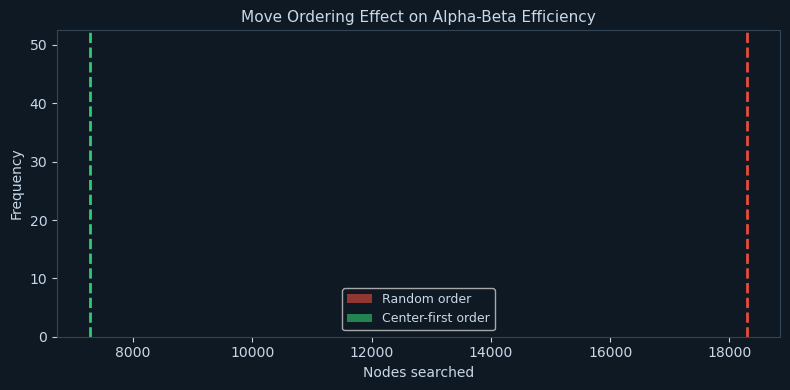

In [32]:
CENTER_PRIORITY = [4, 0, 2, 6, 8, 1, 3, 5, 7]  # center first, then corners, edges

def count_nodes_ordered(board, player):
    counter = [0]
    def ab(board, player, alpha, beta):
        counter[0] += 1
        winner = get_winner(board)
        if winner is not None: return winner
        if EMPTY not in board: return 0
        moves = sorted(get_moves(board),
                       key=lambda m: CENTER_PRIORITY.index(m))
        if player == X:
            best = -math.inf
            for m in moves:
                score = ab(make_move(board, m, player), -player, alpha, beta)
                best  = max(best, score)
                alpha = max(alpha, best)
                if beta <= alpha: break
            return best
        else:
            best = math.inf
            for m in moves:
                score = ab(make_move(board, m, player), -player, alpha, beta)
                best  = min(best, score)
                beta  = min(beta, best)
                if beta <= alpha: break
            return best
    ab(board, player, -math.inf, math.inf)
    return counter[0]

trials = 50
n_random  = [count_nodes(random_board_after_k_moves(0), X, use_ab=True)
             for _ in range(trials)]
n_ordered = [count_nodes_ordered(random_board_after_k_moves(0), X)
             for _ in range(trials)]

print(f"Alpha-beta, random move order  : {np.mean(n_random):.0f} nodes (avg)")
print(f"Alpha-beta, center-first order : {np.mean(n_ordered):.0f} nodes (avg)")
print(f"Improvement from ordering      : {(1 - np.mean(n_ordered)/np.mean(n_random))*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(n_random,  bins=20, color="#e74c3c", alpha=0.6, label="Random order")
ax.hist(n_ordered, bins=20, color="#2ecc71", alpha=0.6, label="Center-first order")
ax.axvline(np.mean(n_random),  color="#e74c3c", linewidth=2, linestyle="--")
ax.axvline(np.mean(n_ordered), color="#2ecc71", linewidth=2, linestyle="--")
ax.set_xlabel("Nodes searched")
ax.set_ylabel("Frequency")
ax.set_title("Move Ordering Effect on Alpha-Beta Efficiency", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Connect Four: Heuristic Search
Connect Four's game tree complexity is approximately 10²¹ far too large
to solve exhaustively in real time. Instead, we search to a fixed **depth
limit** and use a **heuristic evaluation function** to estimate how good a
position is without solving it completely.

This is the core idea behind practical game AI: you can't see to the end,
so you estimate.

### Heuristic design
A good heuristic should be:
- **Fast to compute**: evaluated millions of times per move
- **Correlated with winning**: better positions should score higher
- **Smooth**: small positional changes should give small score changes

Ours counts "open windows" a sequences of 4 consecutive cells where
a player could still complete four-in-a-row, weighted by how many
pieces are already there.

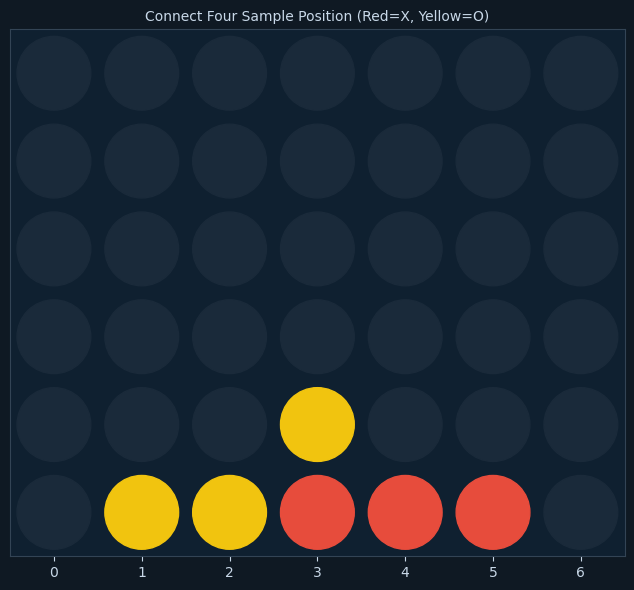

Valid moves: [0, 1, 2, 3, 4, 5, 6]


In [33]:
# Connect Four engine

ROWS, COLS = 6, 7
C4_EMPTY, C4_X, C4_O = 0, 1, -1

def c4_empty_board():
    return [[C4_EMPTY]*COLS for _ in range(ROWS)]

def c4_drop(board, col, player):
    """Drop a piece into col. Returns new board or None if invalid."""
    for row in range(ROWS-1, -1, -1):
        if board[row][col] == C4_EMPTY:
            new = deepcopy(board)
            new[row][col] = player
            return new
    return None

def c4_valid_moves(board):
    return [c for c in range(COLS) if board[0][c] == C4_EMPTY]

def c4_winner(board):
    """Return player if they have four in a row, else None."""
    for r in range(ROWS):
        for c in range(COLS):
            p = board[r][c]
            if p == C4_EMPTY: continue
            # Horizontal
            if c+3 < COLS and all(board[r][c+i]==p for i in range(4)): return p
            # Vertical
            if r+3 < ROWS and all(board[r+i][c]==p for i in range(4)): return p
            # Diagonal right-down
            if r+3 < ROWS and c+3 < COLS and all(board[r+i][c+i]==p for i in range(4)): return p
            # Diagonal left-down
            if r+3 < ROWS and c-3 >= 0 and all(board[r+i][c-i]==p for i in range(4)): return p
    return None

def c4_is_terminal(board):
    return c4_winner(board) is not None or not c4_valid_moves(board)

def draw_c4_board(board, ax=None, title=""):
    """Draw a Connect Four board with colored pieces."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    colors = {C4_X: "#e74c3c", C4_O: "#f1c40f", C4_EMPTY: "#1a2a3a"}
    ax.set_xlim(-0.5, COLS-0.5)
    ax.set_ylim(-0.5, ROWS-0.5)
    ax.set_facecolor("#0f2030")
    ax.set_aspect("equal")
    for r in range(ROWS):
        for c in range(COLS):
            circle = plt.Circle(
                (c, ROWS-1-r), 0.42,
                color=colors[board[r][c]], zorder=2
            )
            ax.add_patch(circle)
    ax.set_xticks(range(COLS))
    ax.set_xticklabels([str(c) for c in range(COLS)])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    ax.grid(False)
    return ax

# Demo board
demo = c4_empty_board()
for move in [(3,C4_X),(3,C4_O),(4,C4_X),(2,C4_O),(5,C4_X),(1,C4_O)]:
    demo = c4_drop(demo, move[0], move[1])

fig, ax = plt.subplots(figsize=(8, 6))
draw_c4_board(demo, ax, title="Connect Four Sample Position (Red=X, Yellow=O)")
plt.tight_layout()
plt.show()
print("Valid moves:", c4_valid_moves(demo))

In [34]:
# Heuristic evaluation function

WINDOW_SCORES = {4: 1000, 3: 5, 2: 2}

def score_window(window, player):
    """Score a 4-cell window for the given player."""
    opp = -player
    p_count   = window.count(player)
    opp_count = window.count(opp)
    empty     = window.count(C4_EMPTY)

    if opp_count > 0:
        return 0   # Blocked by opponent
    return WINDOW_SCORES.get(p_count, 0)

def heuristic(board, player):
    """
    Evaluate board position for player.
    Positive = good for player, Negative = bad.
    """
    winner = c4_winner(board)
    if winner == player:   return 100_000
    if winner == -player:  return -100_000

    score = 0
    opp   = -player

    # All 4-cell windows: horizontal, vertical, diagonal
    windows = []
    for r in range(ROWS):
        for c in range(COLS - 3):
            windows.append([board[r][c+i] for i in range(4)])
    for r in range(ROWS - 3):
        for c in range(COLS):
            windows.append([board[r+i][c] for i in range(4)])
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            windows.append([board[r+i][c+i] for i in range(4)])
            windows.append([board[r+3-i][c+i] for i in range(4)])

    for window in windows:
        score += score_window(window, player)
        score -= score_window(window, opp)

    # Center column preference
    center = [board[r][COLS//2] for r in range(ROWS)]
    score  += center.count(player) * 3

    return score

# Test the heuristic
b_test = c4_empty_board()
for c in [3, 3, 3, 4]:
    b_test = c4_drop(b_test, c, C4_X)
for c in [2, 2]:
    b_test = c4_drop(b_test, c, C4_O)

print(f"Heuristic score for X: {heuristic(b_test, C4_X)}")
print(f"(Positive = X is ahead)")

Heuristic score for X: 18
(Positive = X is ahead)


In [35]:
# Connect Four minimax with alpha-beta and depth limit

def c4_minimax(board, depth, player, alpha, beta, maximizing):
    """
    Depth-limited minimax with alpha-beta for Connect Four.
    Returns (score, best_column).
    """
    if c4_winner(board) is not None or not c4_valid_moves(board) or depth == 0:
        return heuristic(board, C4_X), None

    moves = c4_valid_moves(board)
    # Center-first move ordering
    moves.sort(key=lambda c: abs(c - COLS//2))

    if maximizing:
        best_score = -math.inf
        best_col   = moves[0]
        for col in moves:
            child = c4_drop(board, col, player)
            score, _ = c4_minimax(child, depth-1, -player,
                                   alpha, beta, False)
            if score > best_score:
                best_score = score
                best_col   = col
            alpha = max(alpha, score)
            if beta <= alpha: break
        return best_score, best_col
    else:
        best_score = math.inf
        best_col   = moves[0]
        for col in moves:
            child = c4_drop(board, col, player)
            score, _ = c4_minimax(child, depth-1, -player,
                                   alpha, beta, True)
            if score < best_score:
                best_score = score
                best_col   = col
            beta = min(beta, score)
            if beta <= alpha: break
        return best_score, best_col

# Quick test
board = c4_empty_board()
score, col = c4_minimax(board, depth=4, player=C4_X,
                         alpha=-math.inf, beta=math.inf, maximizing=True)
print(f"Depth-4 minimax from empty board: best column = {col}, score = {score}")

Depth-4 minimax from empty board: best column = 3, score = 4


### Exponential growth: depth vs. computation time

One of the most important things to understand about game tree search is
how dramatically computation time grows with depth. Let's measure it.

  Depth 1: 1.5 ms
  Depth 2: 3.7 ms
  Depth 3: 18.5 ms
  Depth 4: 39.1 ms
  Depth 5: 446.7 ms

Each additional ply multiplies search time by roughly b^1
(b = branching factor ≈ 7 for Connect Four)


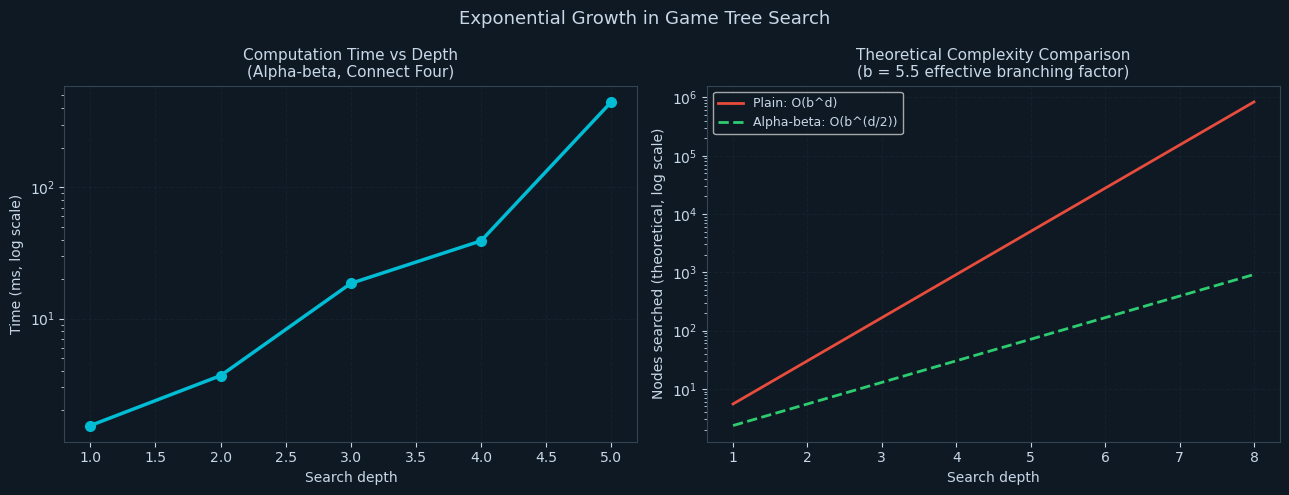

In [36]:
depths      = [1, 2, 3, 4, 5]
times_plain = []
times_ab    = []

board = c4_empty_board()
# Play a few moves for a more interesting position
for col, player in [(3,C4_X),(3,C4_O),(4,C4_X),(2,C4_O)]:
    board = c4_drop(board, col, player)

for d in depths:
    # With alpha-beta
    t0 = time.perf_counter()
    c4_minimax(board, depth=d, player=C4_X,
               alpha=-math.inf, beta=math.inf, maximizing=True)
    times_ab.append(time.perf_counter() - t0)
    print(f"  Depth {d}: {times_ab[-1]*1000:.1f} ms")

print()
print("Each additional ply multiplies search time by roughly b^1")
print(f"(b = branching factor ≈ {COLS} for Connect Four)")

# Theoretical curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(depths, [t*1000 for t in times_ab], "o-",
            color="#00bcd4", linewidth=2.5, markersize=7)
ax.set_xlabel("Search depth")
ax.set_ylabel("Time (ms, log scale)")
ax.set_title("Computation Time vs Depth\n(Alpha-beta, Connect Four)", fontsize=11)
ax.grid(alpha=0.35)

ax = axes[1]
# Theoretical node counts: b^d vs b^(d/2)
b = 5.5  # effective branching factor
d_vals = np.linspace(1, 8, 100)
ax.semilogy(d_vals, b**d_vals,    "-",  color="#e74c3c", linewidth=2, label="Plain: O(b^d)")
ax.semilogy(d_vals, b**(d_vals/2),"--", color="#2ecc71", linewidth=2, label="Alpha-beta: O(b^(d/2))")
ax.set_xlabel("Search depth")
ax.set_ylabel("Nodes searched (theoretical, log scale)")
ax.set_title("Theoretical Complexity Comparison\n(b = 5.5 effective branching factor)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.35)

plt.suptitle("Exponential Growth in Game Tree Search", fontsize=13)
plt.tight_layout()
plt.show()

In [37]:
# How much does depth affect play quality?
# Pit shallow (depth 1) vs deeper (depth 3) search

def c4_play_game(x_depth, o_depth, verbose=False):
    """Play a Connect Four game between two minimax players."""
    board  = c4_empty_board()
    player = C4_X
    for turn in range(ROWS * COLS):
        if c4_is_terminal(board): break
        depth = x_depth if player == C4_X else o_depth
        _, col = c4_minimax(board, depth, player,
                             -math.inf, math.inf, player == C4_X)
        if col is None: break
        board  = c4_drop(board, col, player)
        player = -player
    return c4_winner(board) or 0

print("Depth 1 (X) vs Depth 3 (O) for 10 games")
print("(This takes ~30 seconds, a deeper search is slow!)")
results_d1_x = []
for i in range(10):
    result = c4_play_game(x_depth=1, o_depth=3)
    results_d1_x.append(result)
    print(f"  Game {i+1}: {'X wins' if result==1 else 'O wins' if result==-1 else 'Draw'}")

x_wins = results_d1_x.count(1)
o_wins = results_d1_x.count(-1)
draws  = results_d1_x.count(0)
print(f"\nSummary: X (depth 1) wins {x_wins}, O (depth 3) wins {o_wins}, Draws {draws}")
print("Deeper search should win significantly more often.")

Depth 1 (X) vs Depth 3 (O) for 10 games
(This takes ~30 seconds, a deeper search is slow!)
  Game 1: X wins
  Game 2: X wins
  Game 3: X wins
  Game 4: X wins
  Game 5: X wins
  Game 6: X wins
  Game 7: X wins
  Game 8: X wins
  Game 9: X wins
  Game 10: X wins

Summary: X (depth 1) wins 10, O (depth 3) wins 0, Draws 0
Deeper search should win significantly more often.


---
## Summary

| Concept | Key Result |
|---|---|
| Minimax | Guarantees optimal play: tic-tac-toe always draws |
| Alpha-beta pruning | Reduces nodes searched by ~50–80% with no loss in quality |
| Move ordering | Choosing good moves first amplifies pruning i.e. center-first helps |
| Depth limiting | Each additional ply multiplies compute time by ~b; practical limit is depth 5–7 |
| Heuristic evaluation | Allows search beyond computational limits (crucial for complex games) |

## What to explore next
- **Transposition tables**: cache board positions to avoid re-evaluating the same position reached by different move sequences
- **Iterative deepening**: search depth 1, then 2, then 3... using each result to order moves for the next, combining the benefits of BFS and DFS  
- **Monte Carlo Tree Search (MCTS)**: the algorithm behind AlphaGo, which replaced hand-crafted heuristics with random rollouts
- **Neural network evaluation**: replace the heuristic function with a learned model (the AlphaZero approach)